In [1]:

# Only enable critical logging (Optional)
import os
os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

In [2]:
def what_is_installed():
    from pycaret import show_versions
    show_versions()

try:
    what_is_installed()
except ModuleNotFoundError:
    what_is_installed()


System:
    python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
executable: c:\Users\nirintsoart\Desktop\Formation\virtuel\Scripts\python.exe
   machine: Windows-10-10.0.26100-SP0

PyCaret required dependencies:
                 pip: 23.0.1
          setuptools: 65.5.0
             pycaret: 3.3.2
             IPython: 8.37.0
          ipywidgets: 8.1.8
                tqdm: 4.67.1
               numpy: 1.26.4
              pandas: 2.1.4
              jinja2: 3.1.6
               scipy: 1.11.4
              joblib: 1.3.2
             sklearn: 1.4.2
                pyod: 2.0.6
            imblearn: 0.14.0
   category_encoders: 2.7.0
            lightgbm: 4.6.0
               numba: 0.59.1
            requests: 2.32.5
          matplotlib: 3.7.5
          scikitplot: 0.3.7
         yellowbrick: 1.5
              plotly: 6.5.0
    plotly-resampler: Not installed
             kaleido: 1.2.0
           schemdraw: 0.15
         statsmodels: 0.14.6
     

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycaret.datasets import get_data
from pycaret.time_series import TSForecastingExperiment

In [4]:
data = pd.read_excel('../data/new_data.xlsx',index_col=0)
print(data.shape)
data.head()

(144, 1)


,Number of airline passengers
Period,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
data.index = pd.to_datetime(data.index)
print(type(data.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [6]:
print(data.index.freq)

None


In [7]:
data = data.asfreq('MS')   # Début de mois (Month Start)
# data = data.asfreq('M')    # Fin de mois (Month End)
print(data.index.freq)
data.head()

<MonthBegin>


,Number of airline passengers
Period,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [8]:
print(data.isna().sum())
data.duplicated().sum()

Number of airline passengers    0
dtype: int64


26

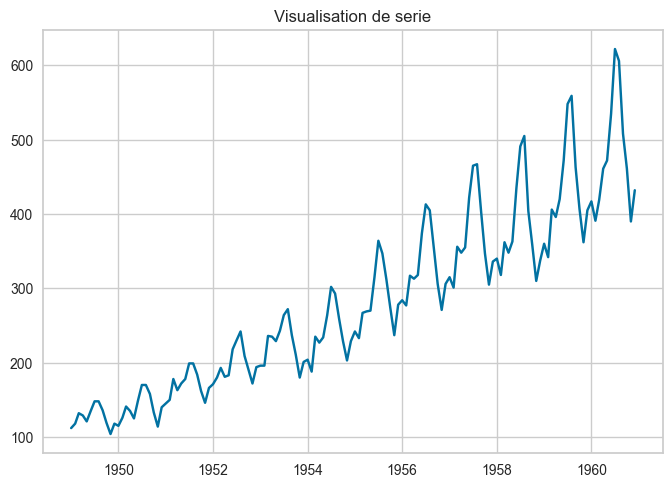

In [9]:
plt.plot(data)
plt.title('Visualisation de serie')
plt.show()

In [10]:
data.describe()

,Number of airline passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose #Importation de module de décomposition

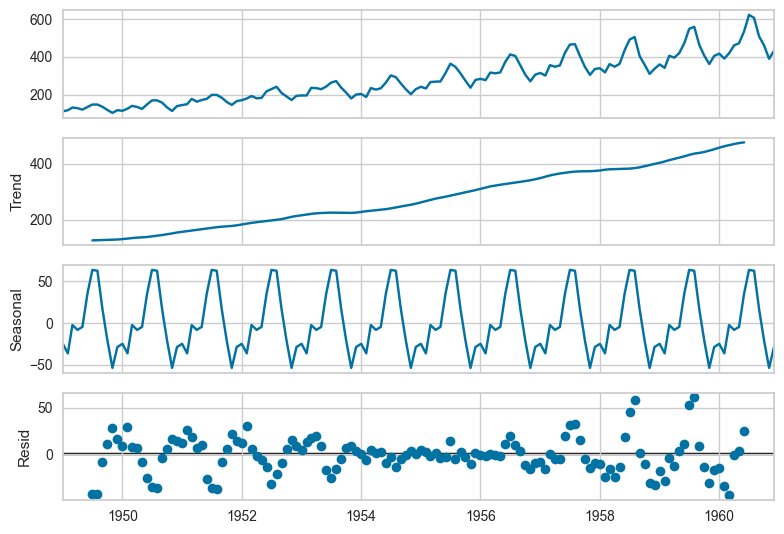

In [12]:
tsa = seasonal_decompose(data, period=12,)
tsa.plot()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller
def stationnaire(data):
    test = adfuller(data)
    print('p-value:',test[1])
    if test[1]<0.05:
        print('Le Série est stationnaire')
    else:
        print('Le Série est non stationnaire')

stationnaire(data=data)

p-value: 0.991880243437641
Le Série est non stationnaire


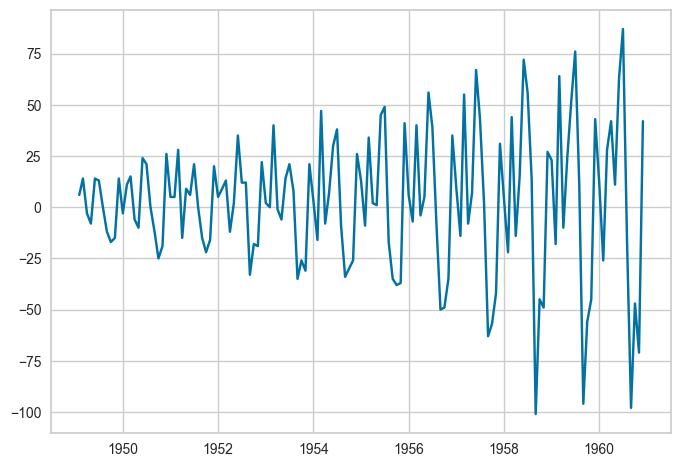

In [14]:
data = data.diff()
plt.plot(data.dropna())
plt.show()

In [15]:
stationnaire(data=data.dropna())

p-value: 0.0542132902838255
Le Série est non stationnaire


In [16]:
data= data.diff(12)
data = data.dropna()
stationnaire(data=data)

p-value: 1.8565116001234705e-28
Le Série est stationnaire


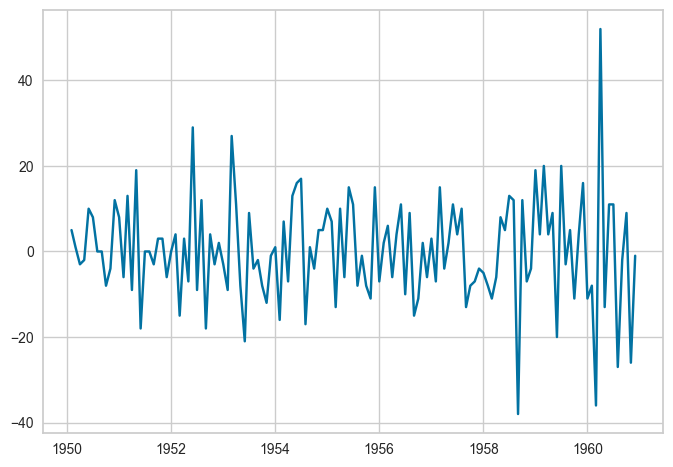

In [17]:
plt.plot(data)
plt.show()

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x600 with 0 Axes>

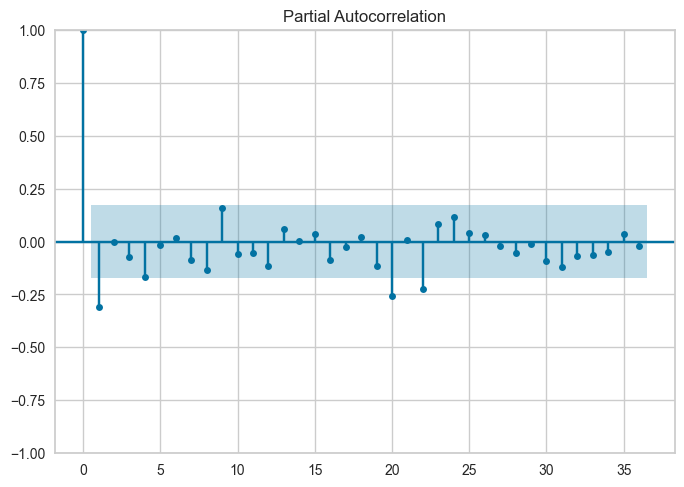

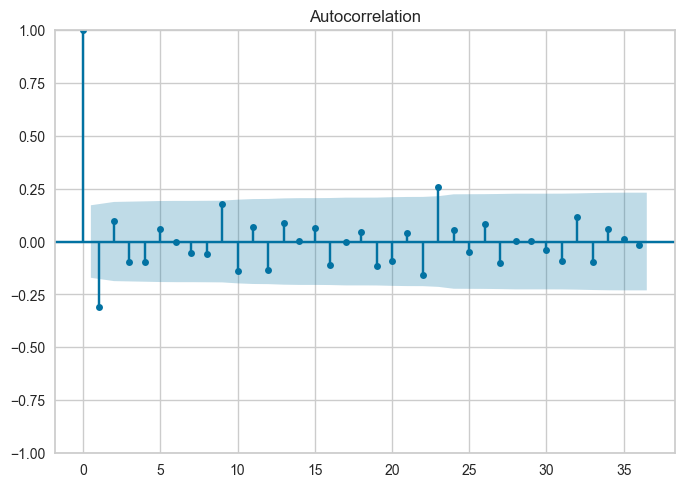

In [19]:
plt.figure(figsize=(10,6))
plot_pacf(data,lags=36)
plot_acf(data,lags=36)
plt.show()

In [20]:
from pycaret.time_series import *

In [21]:
data = pd.read_excel('../data/new_data.xlsx',index_col=0)

In [25]:
exp =TSForecastingExperiment()
s = setup(data = data, fh=12,fold=3,session_id=42)

,Description,Value
0,session_id,42
1,Target,Number of airline passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(144, 1)"
5,Transformed data shape,"(144, 1)"
6,Transformed train set shape,"(132, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [26]:
best_model = compare_models()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
exp_smooth,Exponential Smoothing,0.5716,0.5997,16.7778,19.7963,0.0422,0.0427,0.8954,0.1200
ets,ETS,0.5931,0.6212,17.4165,20.5103,0.0440,0.0445,0.8882,0.1700
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.6666,0.7255,19.6620,24.0121,0.0490,0.0489,0.8465,0.9767
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.6813,0.7866,20.0334,25.9670,0.0491,0.0499,0.8113,0.3967
arima,ARIMA,0.6830,0.6735,20.0069,22.2199,0.0501,0.0507,0.8677,0.1167
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.7004,0.7702,20.6084,25.4401,0.0509,0.0514,0.8215,0.4700
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.7004,0.7703,20.6086,25.4405,0.0509,0.0514,0.8215,0.4300
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.7029,0.7732,20.6816,25.5362,0.0511,0.0516,0.8201,0.4567
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.7048,0.7751,20.7373,25.6005,0.0512,0.0517,0.8193,0.3933
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.7048,0.7751,20.7366,25.6009,0.0512,0.0517,0.8192,0.3900


In [27]:
model = create_model(best_model)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,1956-12,0.4987,0.5736,14.5618,18.7763,0.0366,0.0376,0.8852
1,1957-12,0.5088,0.5368,15.5559,18.2249,0.0420,0.0411,0.9130
2,1958-12,0.7075,0.6887,20.2157,22.3876,0.0479,0.0494,0.8879
Mean,NaT,0.5716,0.5997,16.7778,19.7963,0.0422,0.0427,0.8954
SD,NaT,0.0961,0.0647,2.4646,1.8461,0.0046,0.0049,0.0125
